In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Basic exploration
print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.describe())
print(df['target'].value_counts())  # Check balance


(150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.0

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.iloc[:, :-1])
scaled_df = pd.DataFrame(scaled_features, columns=iris.feature_names)

print(scaled_df.head())
print(scaled_df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.500000e+02      1.500000e+02       1.500000e+02   
mean       -1.468455e-15     -1.823726e-15      -1.610564e-15   
std         1.003350e+00      1.003350e+00       1.003350e+00   
min        -1.870024e+00     -2.433947e+00      -1.567576e+00   
25%        -9.006812e-01     -5.923730e-01      -1.226552e+00   
50%        -5.250608e-02     -1.319795e-01       3.364776e-01   
75%         6.745011e-01      5.586108e-01       7.627583e-01   
max         2.492019e+00

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# One-hot encode labels
y_train_enc = to_categorical(y_train)
y_test_enc = to_categorical(y_test)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(5, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden Layer 1
    Dense(5, activation='relu'),  # Hidden Layer 2
    Dense(3, activation='softmax')  # Output Layer for 3 classes
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train_enc,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3416 - loss: 1.0666 - val_accuracy: 0.2917 - val_loss: 1.0789
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3517 - loss: 1.0419 - val_accuracy: 0.2917 - val_loss: 1.0616
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3674 - loss: 1.0152 - val_accuracy: 0.2917 - val_loss: 1.0449
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4183 - loss: 0.9841 - val_accuracy: 0.2917 - val_loss: 1.0288
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4842 - loss: 0.9955 - val_accuracy: 0.5000 - val_loss: 1.0139
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6148 - loss: 0.9577 - val_accuracy: 0.6250 - val_loss: 0.9998
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6475 - loss: 0.9519 - val_accuracy: 0.6250 - val_loss: 0.9876
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6826 - loss: 0.9553 - val_accuracy: 0.6667 - va

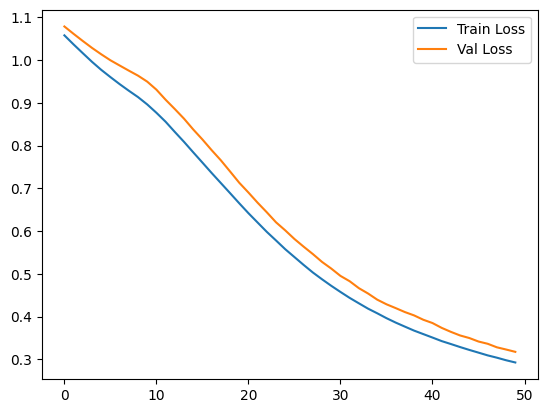

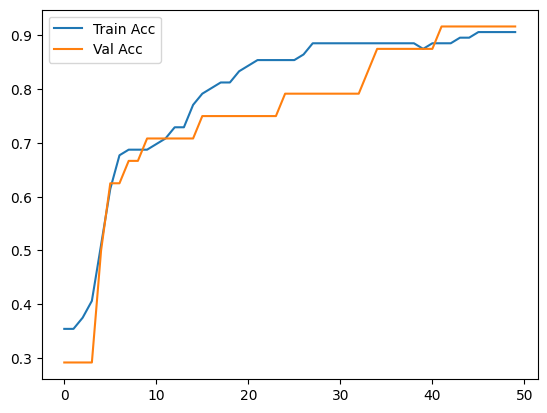

In [7]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.show()

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_enc)
print(f'Test Accuracy: {test_acc:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8333 - loss: 0.3626
Test Accuracy: 0.83


In [9]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from tensorflow.keras.models import clone_model

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = []

for train_idx, val_idx in kf.split(scaled_df, df['target']):
    X_tr, X_val = scaled_df.iloc[train_idx], scaled_df.iloc[val_idx]
    y_tr, y_val = df['target'].iloc[train_idx], df['target'].iloc[val_idx]

    y_tr_enc = to_categorical(y_tr)
    y_val_enc = to_categorical(y_val)

    temp_model = clone_model(model)
    temp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    temp_model.fit(X_tr, y_tr_enc, epochs=50, batch_size=10, verbose=0)

    _, acc = temp_model.evaluate(X_val, y_val_enc, verbose=0)
    acc_scores.append(acc)

print("Average Accuracy across folds:", np.mean(acc_scores))


Average Accuracy across folds: 0.9066666483879089


In [10]:
from tensorflow.keras.layers import Dropout

simple_model = Sequential([
    Dense(5, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

simple_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

simple_history = simple_model.fit(
    X_train, y_train_enc,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.0726 - loss: 1.3354 - val_accuracy: 0.0000e+00 - val_loss: 1.2608
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1270 - loss: 1.3134 - val_accuracy: 0.0000e+00 - val_loss: 1.2353
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1359 - loss: 1.2566 - val_accuracy: 0.0000e+00 - val_loss: 1.2110
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1663 - loss: 1.2220 - val_accuracy: 0.0000e+00 - val_loss: 1.1880
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3086 - loss: 1.1574 - val_accuracy: 0.0833 - val_loss: 1.1662
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2320 - loss: 1.2225 - val_accuracy: 0.0833 - val_loss: 1.1452
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1823 - loss: 1.1670 - val_accuracy: 0.0833 - val_loss: 1.1252
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2309 - loss: 1.1794 - val_accuracy: 0.125

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(
    X_train, y_train_enc,
    epochs=100,
    batch_size=10,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9210 - loss: 0.3053 - val_accuracy: 0.9167 - val_loss: 0.3111
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8952 - loss: 0.3053 - val_accuracy: 0.9167 - val_loss: 0.3052
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9000 - loss: 0.2668 - val_accuracy: 0.9167 - val_loss: 0.3002
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9103 - loss: 0.2934 - val_accuracy: 0.9167 - val_loss: 0.2907
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9204 - loss: 0.2455 - val_accuracy: 0.9167 - val_loss: 0.2872
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9092 - loss: 0.2535 - val_accuracy: 0.9167 - val_loss: 0.2845
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8982 - loss: 0.2466 - val_accuracy: 0.9167 - val_loss: 0.2779
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9137 - loss: 0.2614 - val_accuracy: 0.916